**Задание на лабораторную работу №7**  
Найти шаблон на изображении

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
import sys
import cv2
from sklearn.cluster import MeanShift, estimate_bandwidth

Изменение стандартного размера графиков matplotlib

In [20]:
WIDTH_SIZE = 15
HEIGHT_SIZE = 10
plt.rcParams["figure.figsize"] = [WIDTH_SIZE, HEIGHT_SIZE]

In [21]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Загрузка изображения и шаблона

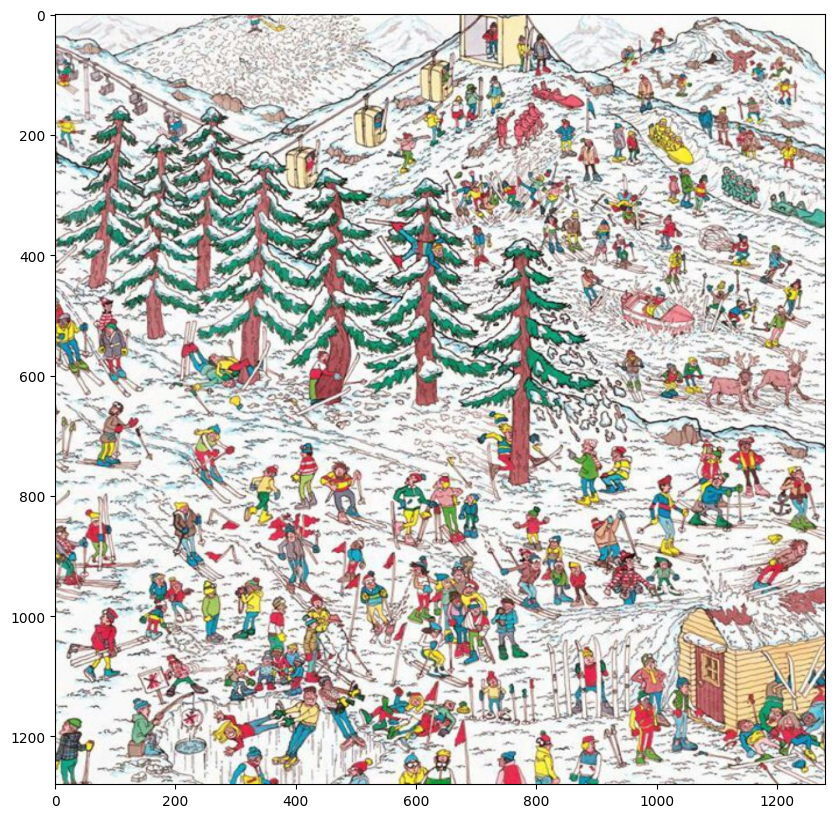

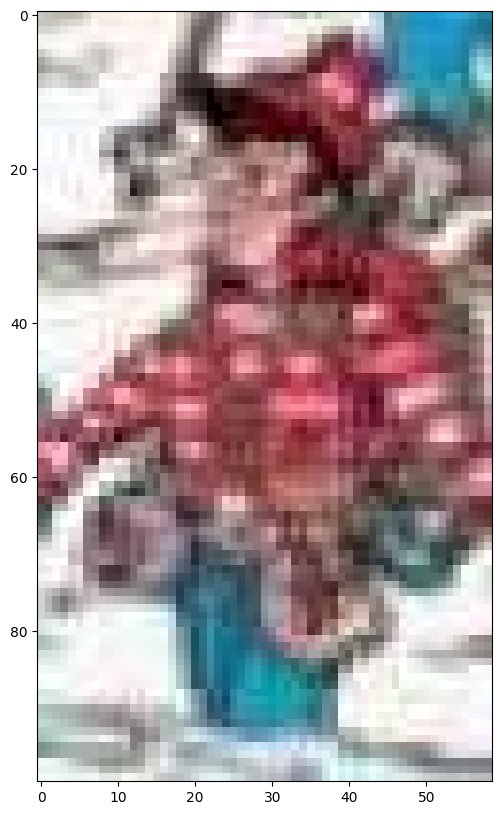

In [22]:
# Загрузка изображения
image = cv2.imread('/content/drive/MyDrive/Image_processing/img.jpg', cv2.COLOR_BGR2RGB)
plt.figure()
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Загрузка шаблона
template = cv2.imread('/content/drive/MyDrive/Image_processing/tmp.jpg')
plt.figure()
plt.imshow(cv2.cvtColor(template, cv2.COLOR_BGR2RGB))

gray_template = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

Использование функции cv.matchTemplate из OpenCV для поиска фрагмента изображения

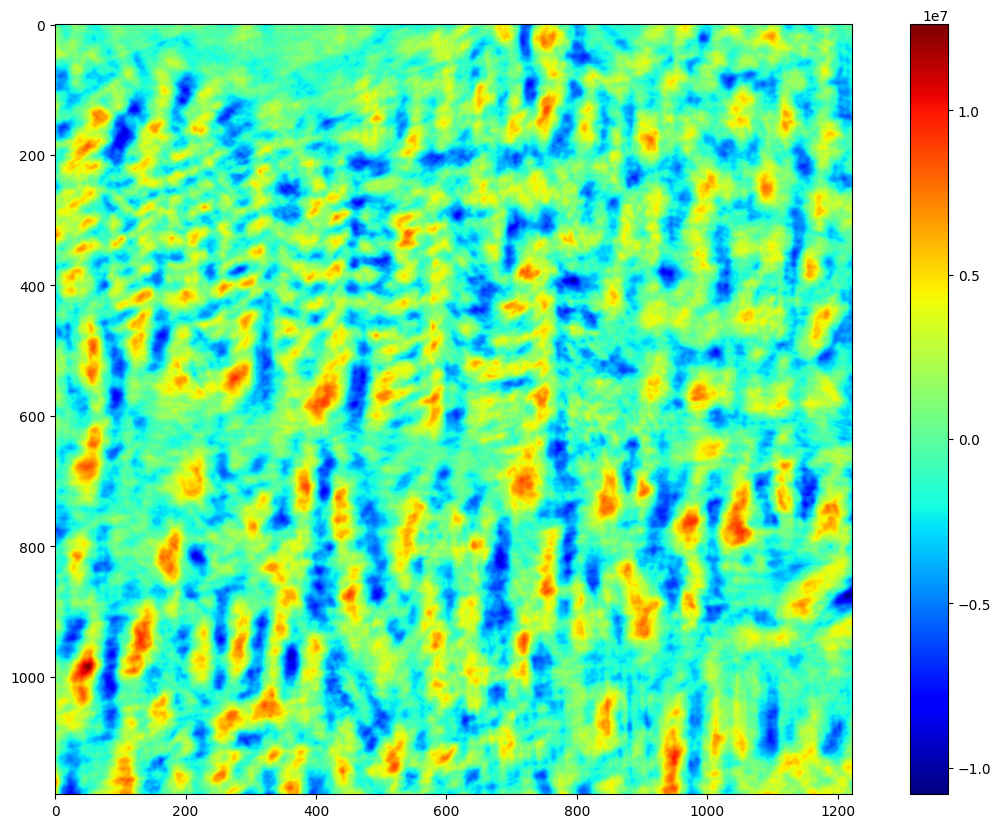

In [23]:
# Размеры шаблона
w, h = template.shape[:-1]

# Вычисление метрики схожести
# в качестве параметров передается изображение, шаблон и тип вычисляемой метрики
res = cv2.matchTemplate(gray_img,gray_template,cv2.TM_CCOEFF)

plt.figure()
plt.imshow(res, cmap='jet')
plt.colorbar()

 Вокруг выделенного максимума обведен прямоугольник с размерами шаблона, отображение результата

Text(0.5, 1.0, 'Обнаруженный фрагмент')

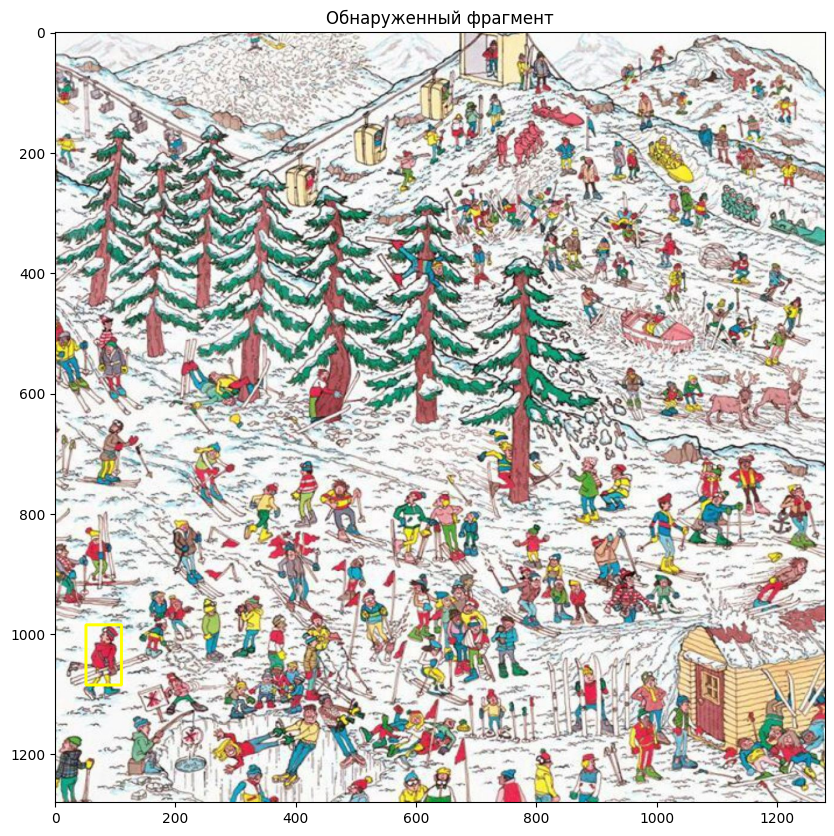

In [24]:
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)
top_left = max_loc
bottom_right = (top_left[0] + template.shape[1], top_left[1] + template.shape[0])

detected_img = image.copy()
cv2.rectangle(detected_img, top_left, bottom_right, (0,255,255), 3)

plt.figure()
plt.imshow(cv2.cvtColor(detected_img, cv2.COLOR_BGR2RGB))
plt.title('Обнаруженный фрагмент')

"Братан, это немножко не то..."  
https://dzen.ru/shorts/667dc0a41ab3cc66a586626c

Шаблон отзеркален, поэтому будем пробовать другие методы поиска его на изображении

Попробуем метод выделения особых точек SIFT

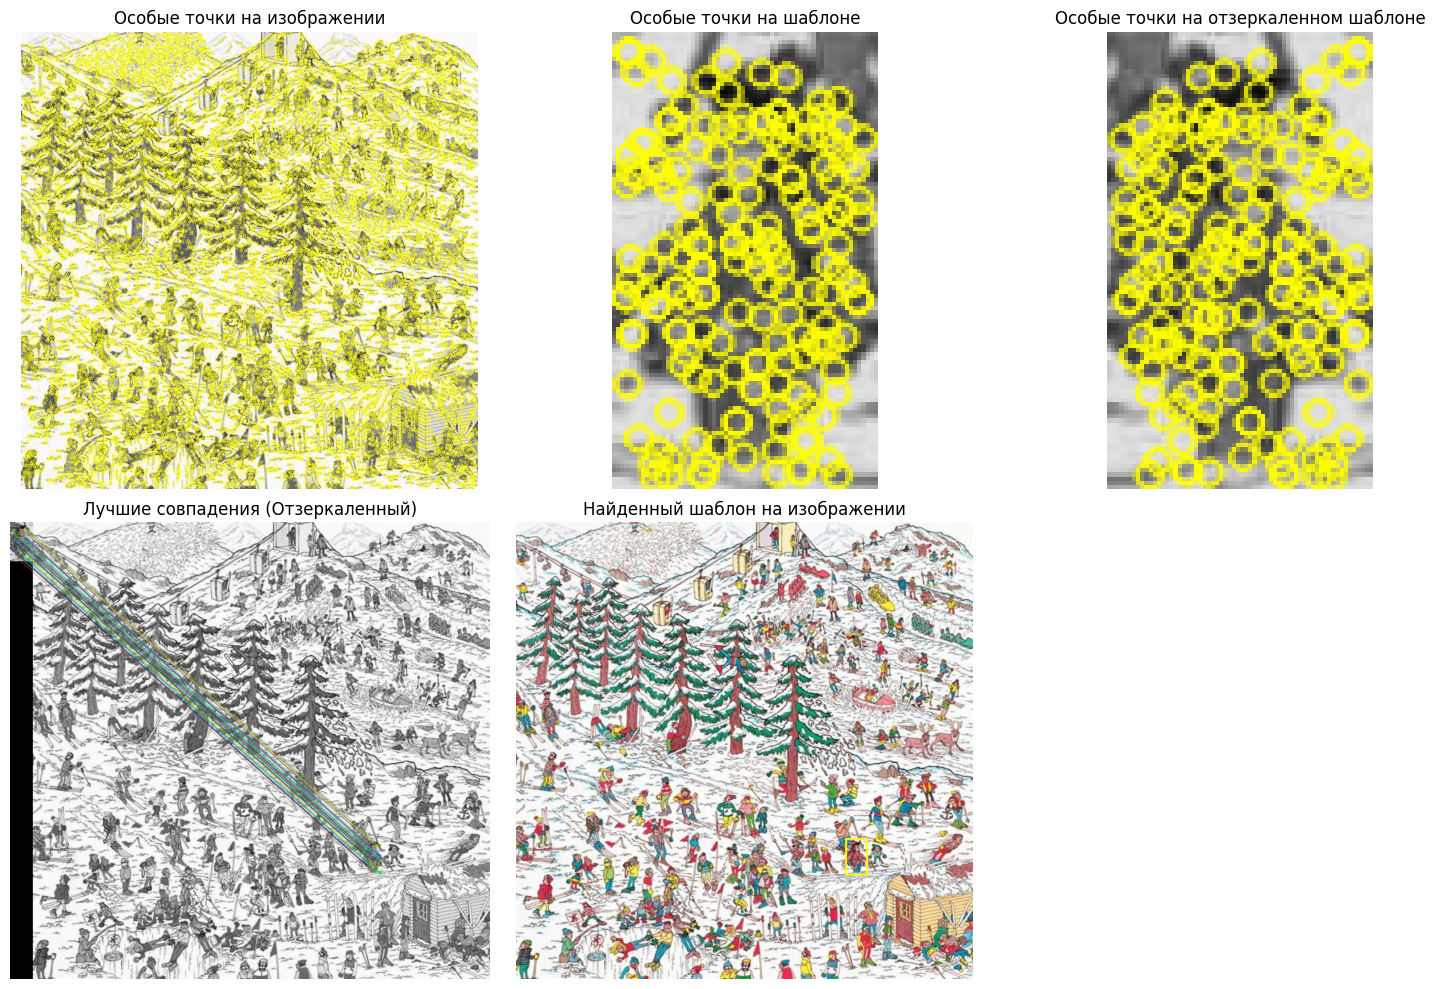

In [25]:
# Параметры преобразования шаблона
scale = 1.1
brightness_coef = 0.9

# Применение масштабирования и изменения яркости к шаблону
template_scaled = cv2.resize(
    np.uint8(brightness_coef * gray_template),
    (int(template.shape[1] * scale), int(template.shape[0] * scale)),
    interpolation=cv2.INTER_AREA
)

# Создание отзеркаленной версии шаблона
template_flipped = cv2.flip(template_scaled, 1)  # 1 - горизонтальное отражение

# Создание детектора SIFT
sift = cv2.SIFT_create()

# Поиск особых точек и дескрипторы
kp_img, des_img = sift.detectAndCompute(gray_img, None)
kp_template, des_template = sift.detectAndCompute(template_scaled, None)
kp_template_flipped, des_template_flipped = sift.detectAndCompute(template_flipped, None)

# Создание BFMatcher
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)  # Для SIFT используем L2 норму

# Поиск совпадений с оригинальным шаблоном
matches_original = bf.knnMatch(des_template, des_img, k=2)

# Поиск совпадений с отзеркаленным шаблоном
matches_flipped = bf.knnMatch(des_template_flipped, des_img, k=2)

# Функция для фильтрации хороших совпадений (тест Лоу)
def filter_good_matches(matches, ratio=0.75):
    good_matches = []
    for m, n in matches:
        if m.distance < ratio * n.distance:
            good_matches.append(m)
    return good_matches

# Фильтрация совпадений
good_original = filter_good_matches(matches_original, ratio=0.75)
good_flipped = filter_good_matches(matches_flipped, ratio=0.75)

# Определяние наилучшей ориентации
if len(good_original) > len(good_flipped):
    good_matches = good_original
    template_used = template_scaled
    kp_template_used = kp_template
    orientation = "Оригинальный"
else:
    good_matches = good_flipped
    template_used = template_flipped
    kp_template_used = kp_template_flipped
    orientation = "Отзеркаленный"

# Сортировка совпадений по расстоянию
good_matches = sorted(good_matches, key=lambda x: x.distance)

# Изображение с особыми точками
plt.subplot(231)
img_kp = cv2.drawKeypoints(gray_img, kp_img, None, color=(0, 255, 255))
plt.imshow(cv2.cvtColor(img_kp, cv2.COLOR_BGR2RGB))
plt.title('Особые точки на изображении')
plt.axis('off')

# Оригинальный шаблон с особыми точками
plt.subplot(232)
template_kp = cv2.drawKeypoints(template_scaled, kp_template, None, color=(255, 255, 0))
plt.imshow(template_kp, cmap='gray')
plt.title('Особые точки на шаблоне')
plt.axis('off')

# Отзеркаленный шаблон с особыми точками
plt.subplot(233)
template_flipped_kp = cv2.drawKeypoints(template_flipped, kp_template_flipped, None, color=(255, 255, 0))
plt.imshow(template_flipped_kp, cmap='gray')
plt.title('Особые точки на отзеркаленном шаблоне')
plt.axis('off')

# Лучшие совпадения
plt.subplot(234)
img_matches = cv2.drawMatches(
    template_used, kp_template_used,
    gray_img, kp_img,
    good_matches[:50], None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)
plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
plt.title(f'Лучшие совпадения ({orientation})')
plt.axis('off')

if len(good_matches) >= 4:
    # Получение координат совпадающих точек
    src_pts = np.float32([kp_template_used[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp_img[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # Нахождение матрицы гомографии
    M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    if M is not None:
        # Углы шаблона
        h, w = template_used.shape
        pts = np.float32([[0, 0], [0, h-1], [w-1, h-1], [w-1, 0]]).reshape(-1, 1, 2)

        # Преобразование углов шаблона в координаты изображения
        dst = cv2.perspectiveTransform(pts, M)

        # Отрисовка прямоугольника на исходном изображении
        img_with_rect = image.copy()
        img_with_rect = cv2.polylines(img_with_rect, [np.int32(dst)], True, (0, 255, 255), 3, cv2.LINE_AA)

        plt.subplot(235)
        plt.imshow(cv2.cvtColor(img_with_rect, cv2.COLOR_BGR2RGB))
        plt.title('Найденный шаблон на изображении')
        plt.axis('off')


plt.tight_layout()
plt.show()

Теперь шаблон найден верно